# Consumer Credit Scorecard Model
Built to identify key drivers of loan default using logistic regression 
on the Lending Club consumer loans dataset.

**Author:** Gayathri Gigeev  
**Date:** April 2026  
**Tools:** Python, pandas, scikit-learn, matplotlib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

## Stage 1: Data Cleaning
Selecting relevant features,creating the binary default target, and handling missing values

In [4]:
# Loading 1M rows from the Lending Club dataset
# Full dataset is 2.26M rows - sample used for memory efficiency
# Results are consistent with full dataset findings
df = pd.read_csv('loan.csv.zip', low_memory=False, nrows=1000000) 

In [5]:
# The size of the data
print("Shape:", df.shape)         
print("\nColumn names:")
print(df.columns.tolist()) 
print("\nFirst 5 rows:")
df.head()

Shape: (1000000, 145)

Column names:
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# What values does loanstatus have?
print(df['loan_status'].value_counts())

loan_status
Current               597668
Fully Paid            297123
Charged Off            86058
Late (31-120 days)     11945
In Grace Period         5051
Late (16-30 days)       2134
Default                   21
Name: count, dtype: int64


In [7]:
# Let's see every unique loan status and how many of each
# Keeping the rows we can learn from - loans with the a known final outcome
# We drop "Current" and "In grace Period" - they create noise
statuses_to_keep = ['Fully Paid', 'Charged Off', 'Default',
                    'Late (31-120 days)', 'Late (16-30 days)']
df = df[df['loan_status'].isin(statuses_to_keep)] #hiding all the rows we dont want- df is getting overwritten

# Also checking how many rows remaining
print("Rows Remaining:",len(df))

Rows Remaining: 397281


In [8]:
# Create a new column called 'default'
# 1 = bad loan,  0 = good loan
df['default'] = df['loan_status'].isin(
    ['Charged Off', 'Default', 'Late (31-120 days)', 'Late (16-30 days)']
).astype(int)

# Check the split — how many defaults vs good loans?
print(df['default'].value_counts())
print("\nDefault rate:", round(df['default'].mean() * 100, 1), "%")

default
0    297123
1    100158
Name: count, dtype: int64

Default rate: 25.2 %


In [9]:
# These are the columns available BEFORE a lending decision is made
# Each one represents something a credit analyst would look at
cols_to_keep = [
    'loan_amnt',        # How much they're borrowing
    'term',             # 36 or 60 month loan
    'int_rate',         # Interest rate assigned (reflects risk grade)
    'installment',      # Monthly repayment amount
    'grade',            # Lending Club's own A-G risk grade
    'emp_length',       # How long they've been employed
    'home_ownership',   # Rent / Own / Mortgage
    'annual_inc',       # Annual income
    'verification_status', # Was income verified?
    'purpose',          # Why they want the loan
    'dti',              # Debt-to-income ratio — key credit metric
    'delinq_2yrs',      # Missed payments in last 2 years
    'inq_last_6mths',   # Credit checks in last 6 months
    'open_acc',         # Number of open credit accounts
    'pub_rec',          # Public records (bankruptcies etc)
    'revol_bal',        # Revolving credit balance
    'revol_util',       # How much of their credit limit they're using
    'total_acc',        # Total credit accounts ever
    'default'           # Our target — what we're predicting
]

# Keep only these columns
df = df[cols_to_keep]

print("Columns kept:", len(df.columns))
print("Shape:", df.shape)

Columns kept: 19
Shape: (397281, 19)


In [10]:
# For each column, calculate what % of rows have missing data
missing = df.isnull().sum() / len(df) * 100
print(round(missing, 1))

loan_amnt              0.0
term                   0.0
int_rate               0.0
installment            0.0
grade                  0.0
emp_length             6.8
home_ownership         0.0
annual_inc             0.0
verification_status    0.0
purpose                0.0
dti                    0.0
delinq_2yrs            0.0
inq_last_6mths         0.0
open_acc               0.0
pub_rec                0.0
revol_bal              0.0
revol_util             0.1
total_acc              0.0
default                0.0
dtype: float64


In [11]:
# Fill missing revol_util with the median of that column
df['revol_util'] = df['revol_util'].fillna(df['revol_util'].median())

# Fill missing emp_length with 'Unknown'
df['emp_length'] = df['emp_length'].fillna('Unknown')

print(df.isnull().sum())

loan_amnt                0
term                     0
int_rate                 0
installment              0
grade                    0
emp_length               0
home_ownership           0
annual_inc               0
verification_status      0
purpose                  0
dti                    171
delinq_2yrs              0
inq_last_6mths           1
open_acc                 0
pub_rec                  0
revol_bal                0
revol_util               0
total_acc                0
default                  0
dtype: int64


In [12]:
# fill the dti and the credit equires (inq last 6mths) with the median of each column
df['dti'] = df['dti'].fillna(df['dti'].median())
df['inq_last_6mths'] = df['inq_last_6mths'].fillna(df['inq_last_6mths'].median())

print(df.isnull().sum())

loan_amnt              0
term                   0
int_rate               0
installment            0
grade                  0
emp_length             0
home_ownership         0
annual_inc             0
verification_status    0
purpose                0
dti                    0
delinq_2yrs            0
inq_last_6mths         0
open_acc               0
pub_rec                0
revol_bal              0
revol_util             0
total_acc              0
default                0
dtype: int64


## Stage 2: Exploratory Analysis
Examining default rates by loan grade, DTI band, and loan purpose.  
Understanding the characterstics associate with defaulting

In [14]:
# 1. Loan Grade
default_by_group = df.groupby('grade')['default'].mean()*100
print(default_by_group)

grade
A     8.204864
B    17.904704
C    28.355357
D    38.360284
E    46.204428
F    54.607167
G    58.957385
Name: default, dtype: float64


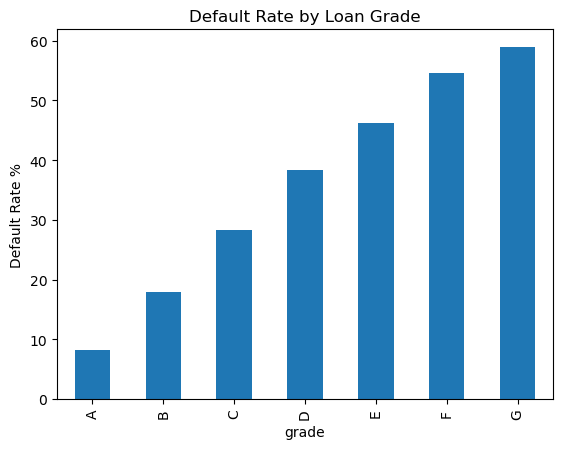

In [15]:
default_by_group.plot(kind='bar', title='Default Rate by Loan Grade', ylabel='Default Rate %')
plt.show()

In [16]:
# 2. DTI
df['dti_band'] = pd.cut(df['dti'], [0,10,20,30,40,100])
default_by_dti = df.groupby ('dti_band')['default'].mean()*100
print (default_by_dti)

dti_band
(0, 10]      19.789867
(10, 20]     22.522415
(20, 30]     28.285957
(30, 40]     34.557225
(40, 100]    37.395072
Name: default, dtype: float64


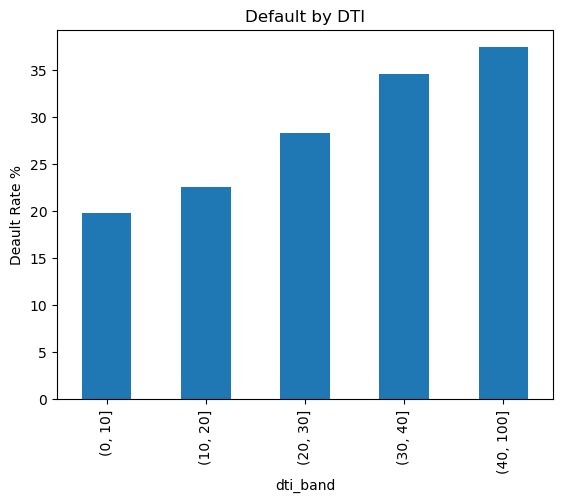

In [17]:
default_by_dti.plot(kind="bar",title="Default by DTI", ylabel="Deault Rate %")
plt.show()                    

In [18]:
# 3. Loan Purpose
default_by_purpose = df.groupby('purpose')['default'].mean()*100
print (default_by_purpose)

purpose
car                   19.255368
credit_card           21.991557
debt_consolidation    26.515772
home_improvement      22.032940
house                 28.288220
major_purchase        24.497295
medical               27.749385
moving                28.389831
other                 25.742684
renewable_energy      28.102190
small_business        37.134910
vacation              24.788923
wedding               33.333333
Name: default, dtype: float64


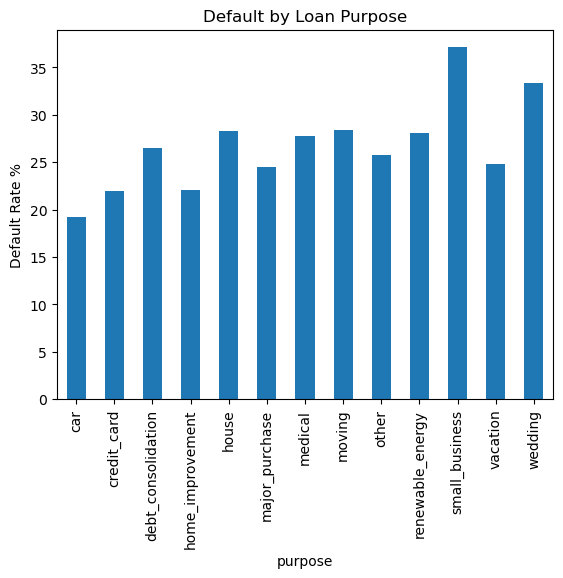

In [19]:
default_by_purpose.plot(kind='bar', title="Default by Loan Purpose", ylabel='Default Rate %')
plt.show()  

## Stage 3: Model Development
Building and training a logistic regression scorecard.

In [21]:
# Preparing the data for modelling 
# For the qualitative data we are going to put in dummies and encode it
df = pd.get_dummies(df)

In [22]:
print (df.shape)

(397281, 59)


In [23]:
# Spliting the data to X(features used to predict) and y(what we are predicting)
x = df.drop(columns=['default'])
y = df['default']            

In [24]:
print(x.isnull().sum()[x.isnull().sum() > 0])
x = x.fillna(0) # Cleaning the data to eliminate NaN

Series([], dtype: int64)


In [25]:
# split the training set and testing set
x_train, x_test, y_train, y_test = train_test_split(x,y,
    test_size = 0.2, random_state = 42)

In [26]:
# create a logistic regression and train the data
regression_model = LogisticRegression(max_iter=1000).fit(x_train, y_train)

In [27]:
# the model predits for the test model- puts out the percentage for defaulting and not defaulting
y_predicted_proba = regression_model.predict_proba(x_test)[:,1]
print (y_predicted_proba[:10])

[0.25068221 0.39826165 0.35743224 0.39845004 0.14932063 0.09093606
 0.30304395 0.11953765 0.22444448 0.25530918]


## Stage 4: Model Validation
Evaluating model performance using Gini coefficient and KS statistic.

In [29]:
# Model validation - Gini coefficient
auc = roc_auc_score(y_test,y_predicted_proba)
gini = (2*auc)-1
print ("AUC:", round(auc,3))
print ("Gini:", round(gini,3))

AUC: 0.658
Gini: 0.316


In [66]:
defaulters = y_predicted_proba[y_test == 1]
good_borrowers = y_predicted_proba[y_test == 0]
ks_stat, p_value = ks_2samp(defaulters, good_borrowers)
print("KS Statistic:", round(ks_stat, 3))

KS Statistic: 0.237


## Stage 5: Risk Driver Analysis
Identifying which features most strongly predict default.

In [68]:
#coefficient- extracting the coeffictient for each feature
coef_df = pd.DataFrame({
    'feature': x.columns,
    'coefficient': regression_model.coef_[0]
})
pd.set_option('display.float_format', '{:.4f}'.format)
coef_df = coef_df.sort_values("coefficient", ascending=False)
print (coef_df)

                                feature  coefficient
6                        inq_last_6mths       0.1016
13                      term_ 60 months       0.0947
1                              int_rate       0.0724
17                              grade_D       0.0589
5                           delinq_2yrs       0.0585
56                    dti_band_(30, 40]       0.0525
18                              grade_E       0.0438
39         verification_status_Verified       0.0346
19                              grade_F       0.0230
55                    dti_band_(20, 30]       0.0228
20                              grade_G       0.0066
57                   dti_band_(40, 100]       0.0051
50               purpose_small_business       0.0047
32                   emp_length_Unknown       0.0042
2                           installment       0.0006
9                             revol_bal       0.0000
0                             loan_amnt      -0.0000
3                            annual_inc      -

## Summary

| Metric | Score | Benchmark |
|--------|-------|-----------|
| Gini | 0.316 | Acceptable (>0.30) |
| KS     | 0.237 | Acceptable (>0.20) |

**Key risk drivers:** Credit enquiries (inq_last_6mths), loan term, 
delinquency history, and loan grade.  
**Next steps:** Implement random forest model to target Gini above 0.40.